In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/GNSS_csir/LSTM_Master_Dataset_2010_2025.csv')
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Check temperature peak hour - should be 13:00-15:00 LST for Bangalore
df['hour'] = df['Datetime'].dt.hour
print("Mean temperature by hour:")
print(df.groupby('hour')['Temperature_C'].mean().round(2))

# Also check PWV peak hour - should be afternoon/evening during monsoon
print("\nMean PWV by hour:")
print(df.groupby('hour')['PWV'].mean().round(2))

Mounted at /content/drive
Mean temperature by hour:
hour
0     20.18
1     19.77
2     19.43
3     19.13
4     18.88
5     18.69
6     19.46
7     21.55
8     24.28
9     26.63
10    28.32
11    29.49
12    30.17
13    30.35
14    30.05
15    29.32
16    28.08
17    25.81
18    24.19
19    23.41
20    22.66
21    21.94
22    21.27
23    20.68
Name: Temperature_C, dtype: float64

Mean PWV by hour:
hour
0     31.45
1     31.39
2     31.33
3     31.27
4     31.26
5     31.32
6     31.51
7     31.76
8     31.99
9     32.27
10    32.70
11    33.22
12    33.69
13    34.03
14    34.26
15    34.29
16    34.13
17    33.83
18    33.47
19    33.06
20    32.59
21    32.15
22    31.87
23    31.72
Name: PWV, dtype: float64


Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/drive/MyDrive/GNSS_csir

  STEP 1: Loading Master Dataset
  Rows loaded    : 134,715
  Date range     : 2010-01-05 02:00:00 → 2025-12-31 23:00:00
  Missing values : 0
  Feature columns: 13
  Target column  : Precipitation_mm

  All expected columns verified ✓

  STEP 2: Scaling Features and Target
  Feature scaler fitted on 13 features
  Target scaler fitted on Precipitation_mm
  Feature range after scaling: [0.000, 1.000]
  Target range after scaling : [0.000, 1.000]

  Original precipitation range:
    Min : 0.000000 mm/hr
    Max : 30.6108 mm/hr

  Saved → feature_scaler.gz
  Saved → target_scaler.gz

  STEP 3: Building Sliding Window Sequences
  Lookback  : 48 hours
  Lead time : 6 hours ahead
  Expected sequences: 134,662

  X shape : (134662, 48, 13)  (sequences, timesteps, features)
  y shape : (1346

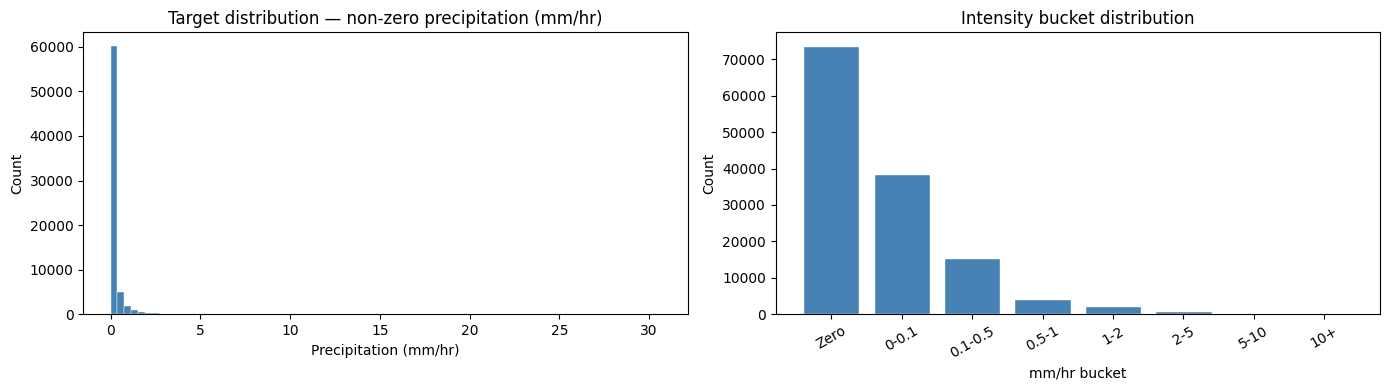

  Plot saved → precipitation_distribution.png

  STEP 6: Saving Arrays
  Saved → X_sequences.npy  (0.336 GB)
  Saved → y_targets.npy  (0.54 MB)

  Reload verification:
    X shape match : True  (134662, 48, 13)
    y shape match : True  (134662, 1)
    X values match: True
    y values match: True

  SEQUENCE PREPARATION COMPLETE

  Files saved to /content/drive/MyDrive/GNSS_csir:
    X_sequences.npy     → (134662, 48, 13)  input sequences
    y_targets.npy       → (134662, 1)  target values
    feature_scaler.gz   → MinMaxScaler for 13 features
    target_scaler.gz    → MinMaxScaler for precipitation

  Settings used:
    Lookback  : 48 hours
    Lead time : 6 hours ahead
    Features  : 13
    Sequences : 134,662
    Zero rain : 48.4%

  Ready for model training!



In [ ]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║   SEQUENCE PREPARATION PIPELINE                                      ║
# ║   Input  : LSTM_Master_Dataset_2010_2025.csv                         ║
# ║   Output : X_sequences.npy  → (134662, 48, 13)                      ║
# ║            y_targets.npy    → (134662, 1)                            ║
# ║            feature_scaler.gz                                         ║
# ║            target_scaler.gz                                          ║
# ║                                                                      ║
# ║   Settings: 48-hour lookback | 6-hour lead time | 13 features        ║
# ║   Run each cell top to bottom in Google Colab                        ║
# ╚══════════════════════════════════════════════════════════════════════╝


# ─────────────────────────────────────────────────────────────────
# CELL 1 — Mount Drive & Imports
# ─────────────────────────────────────────────────────────────────
from google.colab import drive
import os, gzip, io
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

print("Mounting Google Drive...")
drive.mount('/content/drive')

PROJECT_FOLDER = '/content/drive/MyDrive/GNSS_csir'
os.chdir(PROJECT_FOLDER)
print(f"Working directory: {os.getcwd()}")


# ─────────────────────────────────────────────────────────────────
# CELL 2 — Configuration
# ─────────────────────────────────────────────────────────────────
MASTER_CSV   = "LSTM_Master_Dataset_2010_2025.csv"

# Sequence settings
TIME_STEPS   = 48    # hours of past data the model looks back
LEAD_TIME    = 6     # hours ahead to predict

# Output filenames
X_OUT        = "X_sequences.npy"
Y_OUT        = "y_targets.npy"
FEAT_SCALER  = "feature_scaler.gz"
TGT_SCALER   = "target_scaler.gz"

# Feature columns — 13 input features (everything except Datetime and Precipitation_mm)
# Precipitation_mm is the TARGET, not an input feature
# Lag features ARE inputs — they tell the model what happened recently
FEATURE_COLS = [
    'Temperature_C',
    'Relative_Humidity',
    'Surface_Pressure_kPa',
    'ZTD',
    'PWV',
    'hour_sin',
    'hour_cos',
    'month_sin',
    'month_cos',
    'Precipitation_Lag1',
    'Precipitation_Lag3',
    'Precipitation_Lag6',
    'Precipitation_Lag24',
]

TARGET_COL   = 'Precipitation_mm'


# ─────────────────────────────────────────────────────────────────
# CELL 3 — Load Master CSV
# ─────────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("  STEP 1: Loading Master Dataset")
print("="*55)

df = pd.read_csv(MASTER_CSV)
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime').reset_index(drop=True)

print(f"  Rows loaded    : {len(df):,}")
print(f"  Date range     : {df['Datetime'].min()} → {df['Datetime'].max()}")
print(f"  Missing values : {df.isna().sum().sum()}")
print(f"  Feature columns: {len(FEATURE_COLS)}")
print(f"  Target column  : {TARGET_COL}")

# Verify all expected columns exist
missing_cols = [c for c in FEATURE_COLS + [TARGET_COL] if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns in master CSV: {missing_cols}")
print(f"\n  All expected columns verified ✓")


# ─────────────────────────────────────────────────────────────────
# CELL 4 — Scale Features and Target Separately
# ─────────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("  STEP 2: Scaling Features and Target")
print("="*55)

# Fit feature scaler on all 13 input features
feature_scaler = MinMaxScaler(feature_range=(0, 1))
scaled_features = feature_scaler.fit_transform(df[FEATURE_COLS])

# Fit target scaler on precipitation only
# Separate scaler so we can easily inverse-transform predictions later
target_scaler = MinMaxScaler(feature_range=(0, 1))
scaled_target = target_scaler.fit_transform(df[[TARGET_COL]])

print(f"  Feature scaler fitted on {len(FEATURE_COLS)} features")
print(f"  Target scaler fitted on {TARGET_COL}")
print(f"  Feature range after scaling: [{scaled_features.min():.3f}, {scaled_features.max():.3f}]")
print(f"  Target range after scaling : [{scaled_target.min():.3f}, {scaled_target.max():.3f}]")
print(f"\n  Original precipitation range:")
print(f"    Min : {target_scaler.data_min_[0]:.6f} mm/hr")
print(f"    Max : {target_scaler.data_max_[0]:.4f} mm/hr")

# Save both scalers immediately
joblib.dump(feature_scaler, FEAT_SCALER)
joblib.dump(target_scaler,  TGT_SCALER)
print(f"\n  Saved → {FEAT_SCALER}")
print(f"  Saved → {TGT_SCALER}")


# ─────────────────────────────────────────────────────────────────
# CELL 5 — Build Sliding Window Sequences
# ─────────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("  STEP 3: Building Sliding Window Sequences")
print("="*55)
print(f"  Lookback  : {TIME_STEPS} hours")
print(f"  Lead time : {LEAD_TIME} hours ahead")
print(f"  Expected sequences: {len(df) - TIME_STEPS - LEAD_TIME + 1:,}")

X_list, y_list = [], []
n = len(scaled_features)

for i in range(n - TIME_STEPS - LEAD_TIME + 1):
    # X: 48 hours of all 13 features
    X_list.append(scaled_features[i : i + TIME_STEPS])
    # y: precipitation exactly 6 hours after the window ends
    y_list.append(scaled_target[i + TIME_STEPS + LEAD_TIME - 1])

X = np.array(X_list, dtype=np.float32)   # float32 saves memory vs float64
y = np.array(y_list, dtype=np.float32)

print(f"\n  X shape : {X.shape}  (sequences, timesteps, features)")
print(f"  y shape : {y.shape}  (sequences, 1)")
print(f"  X dtype : {X.dtype}")
print(f"  X memory: {X.nbytes / 1e9:.3f} GB")
print(f"  y memory: {y.nbytes / 1e6:.2f} MB")


# ─────────────────────────────────────────────────────────────────
# CELL 6 — Verify Sequence Integrity
# ─────────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("  STEP 4: Sequence Integrity Checks")
print("="*55)

# Check for NaN or Inf in arrays
x_nan  = np.isnan(X).sum()
x_inf  = np.isinf(X).sum()
y_nan  = np.isnan(y).sum()
y_inf  = np.isinf(y).sum()

print(f"  X NaN count  : {x_nan}  {'✓' if x_nan == 0 else '✗ PROBLEM'}")
print(f"  X Inf count  : {x_inf}  {'✓' if x_inf == 0 else '✗ PROBLEM'}")
print(f"  y NaN count  : {y_nan}  {'✓' if y_nan == 0 else '✗ PROBLEM'}")
print(f"  y Inf count  : {y_inf}  {'✓' if y_inf == 0 else '✗ PROBLEM'}")

# Check X value range is within [0, 1]
print(f"  X min        : {X.min():.4f}  {'✓' if X.min() >= 0 else '✗ PROBLEM'}")
print(f"  X max        : {X.max():.4f}  {'✓' if X.max() <= 1 else '✗ PROBLEM'}")
print(f"  y min        : {y.min():.4f}  {'✓' if y.min() >= 0 else '✗ PROBLEM'}")
print(f"  y max        : {y.max():.4f}  {'✓' if y.max() <= 1 else '✗ PROBLEM'}")

# Precipitation distribution in y
zero_pct    = 100 * (y == 0).mean()
nonzero_pct = 100 * (y > 0).mean()
print(f"\n  y zero     : {zero_pct:.1f}%")
print(f"  y non-zero : {nonzero_pct:.1f}%")

# Spot check: manually verify one sequence
idx = 1000
actual_precip = target_scaler.inverse_transform(y[idx].reshape(1,-1))[0][0]
print(f"\n  Spot check sequence {idx}:")
print(f"    Scaled target  : {y[idx][0]:.6f}")
print(f"    Original mm/hr : {actual_precip:.6f}")


# ─────────────────────────────────────────────────────────────────
# CELL 7 — Precipitation Distribution Plot
# ─────────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("  STEP 5: Precipitation Distribution Analysis")
print("="*55)

y_mm = target_scaler.inverse_transform(y).flatten()

print(f"  Min       : {y_mm.min():.6f} mm/hr")
print(f"  Max       : {y_mm.max():.4f} mm/hr")
print(f"  Mean      : {y_mm.mean():.6f} mm/hr")
print(f"  Zero %    : {100*(y_mm==0).mean():.1f}%")
print(f"  P90       : {np.percentile(y_mm, 90):.4f} mm/hr")
print(f"  P99       : {np.percentile(y_mm, 99):.4f} mm/hr")
print(f"  P99.9     : {np.percentile(y_mm, 99.9):.4f} mm/hr")

# Intensity buckets
buckets = [0, 0.001, 0.1, 0.5, 1, 2, 5, 10, 31]
labels  = ['Zero', '0-0.1', '0.1-0.5', '0.5-1', '1-2', '2-5', '5-10', '10+']
print(f"\n  Intensity distribution (mm/hr):")
for i in range(len(buckets)-1):
    cnt = ((y_mm >= buckets[i]) & (y_mm < buckets[i+1])).sum()
    print(f"    {labels[i]:>10} : {cnt:>7,}  ({100*cnt/len(y_mm):.1f}%)")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(y_mm[y_mm > 0], bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_title('Target distribution — non-zero precipitation (mm/hr)')
axes[0].set_xlabel('Precipitation (mm/hr)')
axes[0].set_ylabel('Count')

axes[1].bar(labels, [((y_mm >= buckets[i]) & (y_mm < buckets[i+1])).sum()
                      for i in range(len(buckets)-1)],
            color='steelblue', edgecolor='white')
axes[1].set_title('Intensity bucket distribution')
axes[1].set_xlabel('mm/hr bucket')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('precipitation_distribution.png', dpi=150)
plt.show()
print("  Plot saved → precipitation_distribution.png")


# ─────────────────────────────────────────────────────────────────
# CELL 8 — Save Numpy Arrays
# ─────────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("  STEP 6: Saving Arrays")
print("="*55)

np.save(X_OUT, X)
np.save(Y_OUT, y)

print(f"  Saved → {X_OUT}  ({X.nbytes/1e9:.3f} GB)")
print(f"  Saved → {Y_OUT}  ({y.nbytes/1e6:.2f} MB)")

# Final verification — reload and check
X_check = np.load(X_OUT)
y_check = np.load(Y_OUT)
print(f"\n  Reload verification:")
print(f"    X shape match : {X_check.shape == X.shape}  {X_check.shape}")
print(f"    y shape match : {y_check.shape == y.shape}  {y_check.shape}")
print(f"    X values match: {np.allclose(X_check, X)}")
print(f"    y values match: {np.allclose(y_check, y)}")


# ─────────────────────────────────────────────────────────────────
# CELL 9 — Final Summary
# ─────────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("  SEQUENCE PREPARATION COMPLETE")
print("="*55)
print(f"""
  Files saved to {PROJECT_FOLDER}:
    X_sequences.npy     → {X.shape}  input sequences
    y_targets.npy       → {y.shape}  target values
    feature_scaler.gz   → MinMaxScaler for 13 features
    target_scaler.gz    → MinMaxScaler for precipitation

  Settings used:
    Lookback  : {TIME_STEPS} hours
    Lead time : {LEAD_TIME} hours ahead
    Features  : {len(FEATURE_COLS)}
    Sequences : {len(X):,}
    Zero rain : {100*(y==0).mean():.1f}%

  Ready for model training!
""")

In [3]:
import numpy as np, joblib, gzip, io
with gzip.open('target_scaler.gz','rb') as f:
    ts = joblib.load(io.BytesIO(f.read()))
print(f"Target max: {ts.data_max_[0]:.4f}")

Target max: 30.6108
